# 1A. Introducción y manipulación básica de imágenes con OpenCV

**by Eduardo Cruz**



**Imagen para el ejercicio:** `DPP0012.TIF` (formato TIFF, 1920 x 1080 px, RGB)

## Objetivo
Aplicar las herramientas básicas de [OpenCV](https://docs.opencv.org/4.13.0/d6/d00/tutorial_py_root.html) para:

1. Cargar y visualizar una imagen
2. Cambio de tamaño (resize)
3. Rotación
4. Guardado de resultados



## 1. Configuración inicial

Importamos las librerías necesarias:

- `cv2` (OpenCV): lectura, transformación y escritura de imágenes.
- `numpy`: manejo de arreglos (las imágenes en OpenCV son arreglos de NumPy).
- `matplotlib.pyplot`: visualización, ya que `cv2.imshow()` no es recomendable en Colab.
- `pathlib.Path`: manejo de rutas de forma multiplataforma.

También definimos una función auxiliar `mostrar_img()` para desplegar imágenes en color o en escala de grises sin repetir código, recordando que **OpenCV carga los colores en formato BGR** y `matplotlib` los espera en **RGB**, por lo que hay que convertir con `cv2.cvtColor(img, cv2.COLOR_BGR2RGB)` antes de graficar.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("Versión de OpenCV:", cv2.__version__)

# Función auxiliar para mostrar imágenes en escala de grises o color
def mostrar_img(img, titulo="Imagen", cmap=None, ax=None):
    '''Muestra una imagen de OpenCV con matplotlib

    - Si la imagen tiene 2 dimensiones (H, W) se asume escala de grises
    - Si tiene 3 dimensiones (H, W, 3) se asume BGR y se convierte a RGB
    '''
    mostrar_en_eje = ax is not None
    if not mostrar_en_eje:
        plt.figure(figsize=(5, 5))
        ax = plt.gca()

    if len(img.shape) == 2:  # Escala de grises
        ax.imshow(img, cmap='gray')
    else:  #Color (BGR a RGB para mostrar correctamente)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

    ax.set_title(titulo)
    ax.axis('off')

    if not mostrar_en_eje:
        plt.show()


Versión de OpenCV: 5.0.0


## 2. Carga y visualización

Cargamos la imagen `DPP0012.TIF` en color con `cv2.imread()`. Al ser un archivo TIFF, OpenCV lo soporta de forma nativa (a diferencia de los formatos RAW de cámara, que requerirían `rawpy`).

Después generamos también una versión en escala de grises con `cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)` y mostramos ambas versiones lado a lado.


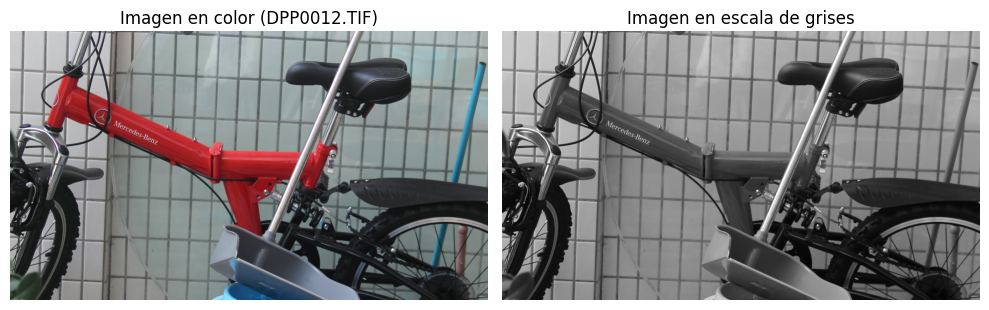

In [3]:
# Ruta a la imagen (ajustar según tu carpeta local o de Colab)
RUTA_IMAGEN = "DPP0012.TIF"

#carga en color (BGR, tal como lo entrega OpenCV)
img_color = cv2.imread(str(RUTA_IMAGEN))

#conversión a escala de grises
img_gris = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)

#visualización lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mostrar_img(img_color, "Imagen en color (DPP0012.TIF)", ax=axes[0])
mostrar_img(img_gris, "Imagen en escala de grises", ax=axes[1])
plt.tight_layout()
plt.show()



**Nota:** la versión en color conserva la información de tono y saturación de la escena, mientras que la versión en escala de grises solo conserva la intensidad luminosa. Para muchas tareas de análisis (bordes, texturas, umbralización) trabajar en escala de grises simplifica el cómputo, aunque se pierde información de color que puede ser relevante para otras tareas (segmentación por color, por ejemplo).


### Información básica de la imagen

Calculamos e imprimimos:

- **Dimensiones** (`img.shape`): alto, ancho y número de canales.
- **Tipo de dato** (`img.dtype`): por ejemplo `uint8` (8 bits por canal).
- **Rango de intensidades** (valores mínimo y máximo) tanto en la versión color como en grises.


In [4]:
def info_imagen(img, nombre="Imagen"):
    print(f"--- {nombre} ---")
    print("Dimensiones (alto, ancho, canales):", img.shape)
    print("Número de canales:", 1 if len(img.shape) == 2 else img.shape[2])
    print("Tipo de dato:", img.dtype)
    print("Valor mínimo de intensidad:", img.min())
    print("Valor máximo de intensidad:", img.max())
    print()

info_imagen(img_color, "Imagen en color")
info_imagen(img_gris, "Imagen en escala de grises")


--- Imagen en color ---
Dimensiones (alto, ancho, canales): (1080, 1920, 3)
Número de canales: 3
Tipo de dato: uint8
Valor mínimo de intensidad: 0
Valor máximo de intensidad: 255

--- Imagen en escala de grises ---
Dimensiones (alto, ancho, canales): (1080, 1920)
Número de canales: 1
Tipo de dato: uint8
Valor mínimo de intensidad: 7
Valor máximo de intensidad: 255



## 3. Cambio de tamaño (resize)

Usamos `cv2.resize()` para generar:

- Una versión al **doble de tamaño (2X)**, usando interpolación `cv2.INTER_LINEAR` (adecuada para agrandar).
- Una versión a la **mitad de tamaño (0.5X)**, usando interpolación `cv2.INTER_AREA` (recomendada por OpenCV para reducir tamaño, ya que evita artefactos de aliasing).

El parámetro `fx`/`fy` indica el factor de escala en cada eje; también se podría indicar un tamaño exacto en píxeles con `dsize`.


Tamaño original:  1920 x 1080  -> shape=(1080, 1920, 3)
Tamaño 2X:        3840 x 2160  -> shape=(2160, 3840, 3)
Tamaño 0.5X:       960 x 540  -> shape=(540, 960, 3)


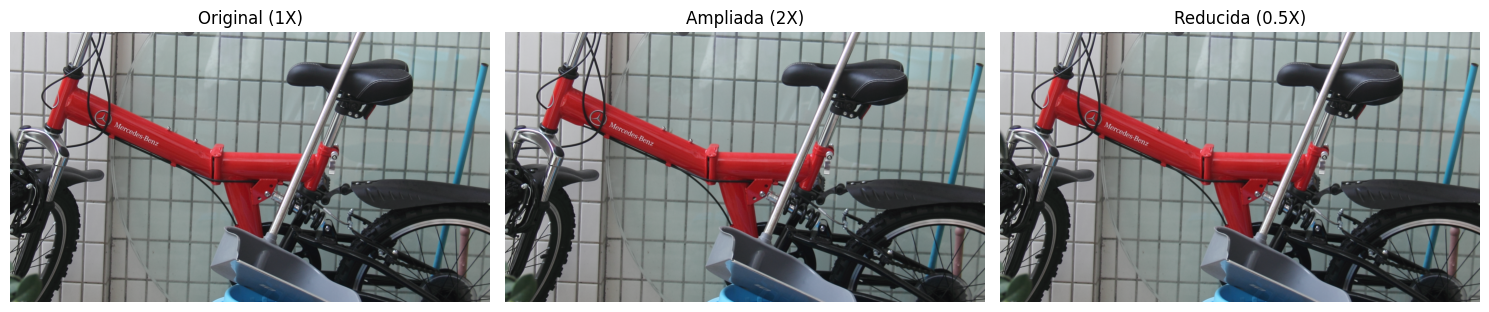

In [5]:
alto, ancho = img_color.shape[:2]

#2X: se duplica el tamaño
img_2x = cv2.resize(img_color, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_LINEAR)

#0.5X: se reduce a la mitad
img_0_5x = cv2.resize(img_color, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

print(f"Tamaño original:  {ancho} x {alto}  -> shape={img_color.shape}")
print(f"Tamaño 2X:        {img_2x.shape[1]} x {img_2x.shape[0]}  -> shape={img_2x.shape}")
print(f"Tamaño 0.5X:       {img_0_5x.shape[1]} x {img_0_5x.shape[0]}  -> shape={img_0_5x.shape}")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
mostrar_img(img_color, "Original (1X)", ax=axes[0])
mostrar_img(img_2x, "Ampliada (2X)", ax=axes[1])
mostrar_img(img_0_5x, "Reducida (0.5X)", ax=axes[2])
plt.tight_layout()
plt.show()


**Implicaciones del cambio de tamaño en tareas de análisis:**

- **Tiempo de procesamiento:** el número de píxeles crece con el cuadrado del factor de escala. La versión 2X tiene 4 veces más píxeles que la original, por lo que cualquier algoritmo que se aplique después (filtrado, detección de bordes, redes neuronales, etc.) tomará más tiempo y memoria. La versión 0.5X, en cambio, acelera el procesamiento al tener 4 veces menos píxeles.
- **Detalle visible:** al ampliar (2X) no se genera información nueva; solo se interpola entre píxeles existentes, por lo que la imagen se ve más grande pero no más nítida (puede incluso notarse borrosa). Al reducir (0.5X) sí se pierde información real (detalles finos, texturas pequeñas) que ya no se puede recuperar.
- **Elección práctica:** en flujos de trabajo reales suele reducirse el tamaño para acelerar tareas de detección/clasificación gruesa, y solo se trabaja a resolución completa cuando se requiere precisión fina (por ejemplo, mediciones exactas o detección de defectos pequeños).


## 4. Rotación

Para rotar la imagen alrededor de su centro usamos:

1. `cv2.getRotationMatrix2D(centro, angulo, escala)`: construye la matriz de transformación afín (rotación + escala).
2. `cv2.warpAffine(img, matriz, (ancho, alto))`: aplica la transformación a la imagen.

Probamos con tres ángulos distintos: **17°, 49° y 99°**. El ángulo es positivo en sentido antihorario.


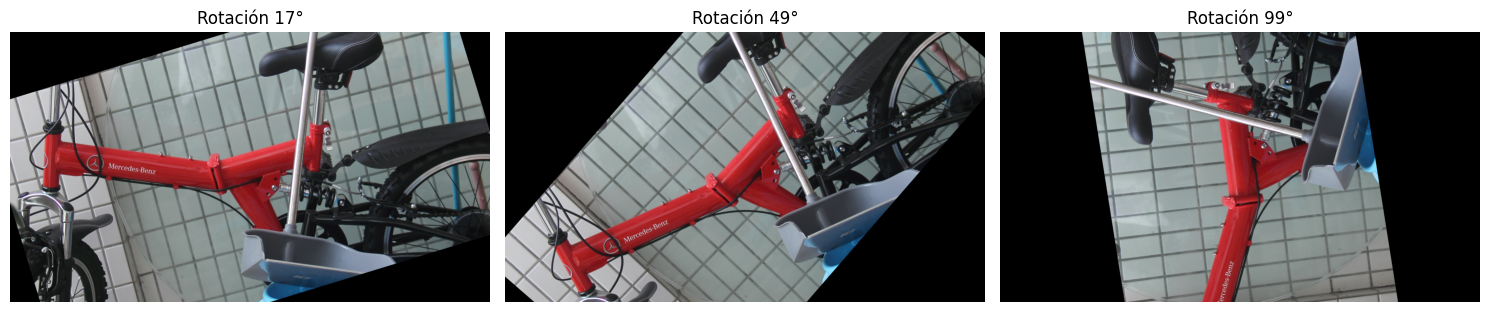

In [6]:
def rotar_imagen(img, angulo):
    (alto, ancho) = img.shape[:2]
    centro = (ancho // 2, alto // 2)
    matriz_rotacion = cv2.getRotationMatrix2D(centro, angulo, 1.0)
    img_rotada = cv2.warpAffine(img, matriz_rotacion, (ancho, alto))
    return img_rotada

angulos = [17, 49, 99]
imgs_rotadas = [rotar_imagen(img_color, a) for a in angulos]

fig, axes = plt.subplots(1, len(angulos), figsize=(15, 6))
for ax, angulo, img_rot in zip(axes, angulos, imgs_rotadas):
    mostrar_img(img_rot, f"Rotación {angulo}°", ax=ax)
plt.tight_layout()
plt.show()


**Observación:** al rotar dentro de un lienzo del mismo tamaño que la imagen original, las esquinas de la imagen rotada pueden quedar recortadas (se pierde contenido en los bordes) y aparecen zonas negras donde antes había imagen. Si se quiere conservar toda la escena, es necesario recalcular el tamaño del lienzo de salida a partir del ángulo de rotación.

**Contextos en los que es necesario corregir la orientación de una imagen antes de analizarla:**

- **Documentos escaneados o fotografiados:** hojas o documentos capturados con un ligero giro deben enderezarse antes de aplicar OCR (reconocimiento de texto), o el reconocimiento fallará o será impreciso.
- **Imágenes satelitales o aéreas:** suelen requerir alinearse con el norte geográfico antes de superponerse con mapas o hacer mediciones de distancia/área.
- **Visión industrial (control de calidad):** piezas que llegan a la cámara con orientación variable (por ejemplo, en una banda transportadora) deben normalizarse en ángulo antes de comparar su forma contra una plantilla de referencia.
- **Imágenes médicas:** placas o resonancias pueden capturarse con distinta orientación del paciente; alinearlas es un paso previo común antes de comparar con estudios anteriores o con un atlas de referencia.


## 5. Guardado de resultados

Guardamos en disco la versión reducida (0.5X) y la versión rotada 47° usando `cv2.imwrite()`. Después las volvemos a cargar con `cv2.imread()` para verificar que el guardado fue correcto.

**Nota:** `cv2.imwrite()` espera la imagen en formato BGR (el mismo en el que OpenCV la maneja internamente), así que no es necesario convertir a RGB antes de guardar.


In [7]:
carpeta_salida = Path("resultados")
carpeta_salida.mkdir(exist_ok=True)

ruta_resize = carpeta_salida / "DPP0012_0.5x.png"
ruta_rotada = carpeta_salida / "DPP0012_rot45.png"

cv2.imwrite(str(ruta_resize), img_0_5x)
cv2.imwrite(str(ruta_rotada), imgs_rotadas[1])  # índice 1 -> 45°

print("Guardado:", ruta_resize.resolve())
print("Guardado:", ruta_rotada.resolve())


Guardado: /content/resultados/DPP0012_0.5x.png
Guardado: /content/resultados/DPP0012_rot45.png


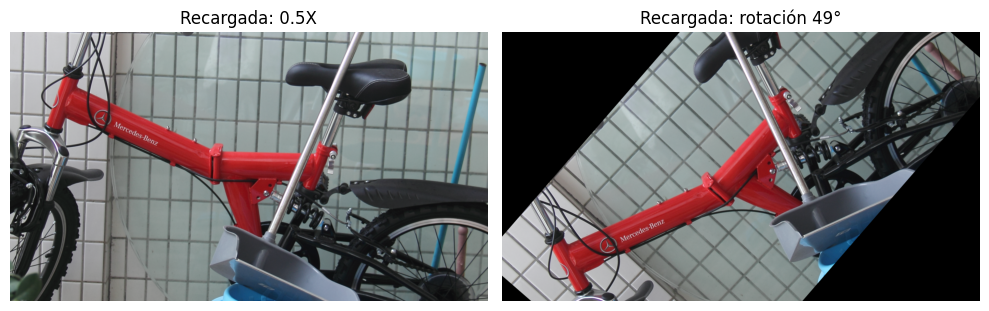

--- Imagen 0.5X recargada desde disco ---
Dimensiones (alto, ancho, canales): (540, 960, 3)
Número de canales: 3
Tipo de dato: uint8
Valor mínimo de intensidad: 3
Valor máximo de intensidad: 255

--- Imagen rotada 49° recargada desde disco ---
Dimensiones (alto, ancho, canales): (1080, 1920, 3)
Número de canales: 3
Tipo de dato: uint8
Valor mínimo de intensidad: 0
Valor máximo de intensidad: 255



In [11]:
# Verificación: volvemos a cargar los archivos guardados
img_resize_check = cv2.imread(str(ruta_resize))
img_rotada_check = cv2.imread(str(ruta_rotada))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mostrar_img(img_resize_check, "Recargada: 0.5X", ax=axes[0])
mostrar_img(img_rotada_check, "Recargada: rotación 49°", ax=axes[1])
plt.tight_layout()
plt.show()

info_imagen(img_resize_check, "Imagen 0.5X recargada desde disco")
info_imagen(img_rotada_check, "Imagen rotada 49° recargada desde disco")


## 6. Conclusión

En esta práctica usamos OpenCV para:

- Cargar una imagen TIFF en color y generar su versión en escala de grises.
- Calcular información básica: dimensiones, número de canales, tipo de dato y rango de intensidades.
- Aplicar transformaciones geométricas: cambio de tamaño (2X y 0.5X) y rotación (17°, 49°, 99°), y reflexionar sobre sus implicaciones prácticas.
- Guardar los resultados en disco y confirmar que se pueden volver a leer correctamente.

Estas operaciones básicas (lectura, redimensionamiento, rotación y guardado) son el punto de partida de casi cualquier flujo de procesamiento digital de imágenes, ya sea para análisis visual, preparación de datos para modelos de visión por computadora, o control de calidad automatizado.
